# Week 7: Weather Data ETL Pipeline

### Data Pipelines & Automation

**AnalystLab Africa Internship**

**Tools:** Python, Pandas, Requests, OpenWeather API

## 1. Project Overview

This project demonstrates the development of a basic ETL (Extract, Transform, Load) pipeline using real-time weather data obtained from the OpenWeather API.

The pipeline extracts weather information for multiple cities, transforms the raw API responses into a structured and analysis-ready dataset using Pandas, and loads the processed data into a CSV file for future analysis.

The project concludes with a basic comparison of weather conditions across the selected cities.

## 2. Objective

The objective of this project is to build a simple and reproducible ETL pipeline that can:

- Extract real-time weather data from the OpenWeather API.
- Transform raw API responses into a structured Pandas DataFrame.
- Clean and prepare the data for analysis.
- Store the processed data as a CSV file.
- Perform basic analysis to identify differences in weather conditions across cities.

## 3. Tools & Libraries

The following tools and Python libraries are used in this project:

| Tool / Library | Purpose |
|---|---|
| Python | Programming language used to build the ETL pipeline |
| Requests | Connects to the OpenWeather API and retrieves data |
| Pandas | Structures, transforms, and analyzes the data |
| Matplotlib | Creates visualizations |
| python-dotenv | Loads the API key securely from an environment file |
| OpenWeather API | Provides real-time weather data |
| Jupyter Notebook | Development and documentation environment |

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 4. API Configuration

The OpenWeather API requires an API key to authenticate requests. The API key is used to access the weather data endpoint.

For this project, the API will be used to retrieve current weather information for Nairobi, London, and Dubai.

In [4]:
API_KEY = "0f8dfea0b422f54c4f3b92d89953a16d"

## 5. Extract — API Connection

The first stage of the ETL pipeline is extraction.

The Requests library is used to send HTTP requests to the OpenWeather API. The API request includes the city name, API key, and metric units so that temperature values are returned in degrees Celsius.

In [5]:
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

cities = ["Nairobi", "London", "Dubai"]

In [6]:
## Collect weather data
weather_data = []

for city in cities:
    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code == 200:
        data = response.json()
        weather_data.append(data)
        print(f"{city}: Data extracted successfully")
    else:
        print(f"{city}: Failed - Status code {response.status_code}")

Nairobi: Data extracted successfully
London: Data extracted successfully
Dubai: Data extracted successfully


In [7]:
print(f"Total cities extracted: {len(weather_data)}")

Total cities extracted: 3


## 6. Inspect Raw Data

The API returns weather information in JSON format. Before transforming the data, the raw responses are inspected to understand their structure and identify the fields required for the final dataset.

In [8]:
weather_data

[{'coord': {'lon': 36.8167, 'lat': -1.2833},
  'weather': [{'id': 804,
    'main': 'Clouds',
    'description': 'overcast clouds',
    'icon': '04d'}],
  'base': 'stations',
  'main': {'temp': 14.93,
   'feels_like': 15.09,
   'temp_min': 14.93,
   'temp_max': 15.62,
   'pressure': 1021,
   'humidity': 100,
   'sea_level': 1021,
   'grnd_level': 841},
  'visibility': 10000,
  'wind': {'speed': 3.09, 'deg': 180},
  'clouds': {'all': 99},
  'dt': 1787032280,
  'sys': {'type': 1,
   'id': 2558,
   'country': 'KE',
   'sunrise': 1787024076,
   'sunset': 1787067541},
  'timezone': 10800,
  'id': 184745,
  'name': 'Nairobi',
  'cod': 200},
 {'coord': {'lon': -0.1257, 'lat': 51.5085},
  'weather': [{'id': 804,
    'main': 'Clouds',
    'description': 'overcast clouds',
    'icon': '04d'}],
  'base': 'stations',
  'main': {'temp': 19.26,
   'feels_like': 19.36,
   'temp_min': 18.36,
   'temp_max': 19.82,
   'pressure': 1011,
   'humidity': 81,
   'sea_level': 1011,
   'grnd_level': 1007},
  'v

## 7. Transform — Structure Data

The raw weather data returned by the API contains nested JSON objects. In the transformation stage, the required fields are extracted and organized into a structured Pandas DataFrame.

The dataset will contain the city name, temperature, humidity, weather condition, wind speed, and date and time.

In [9]:
transformed_data = []

for data in weather_data:
    transformed_data.append({
        "city": data["name"],
        "temperature_c": data["main"]["temp"],
        "humidity_pct": data["main"]["humidity"],
        "weather_condition": data["weather"][0]["description"],
        "wind_speed_mps": data["wind"]["speed"],
        "datetime": pd.to_datetime(data["dt"], unit="s")
    })

In [10]:
weather_df = pd.DataFrame(transformed_data)

weather_df

,city,temperature_c,humidity_pct,weather_condition,wind_speed_mps,datetime
0,Nairobi,14.93,100,overcast clouds,3.09,2026-08-18 05:51:20
1,London,19.26,81,overcast clouds,4.63,2026-08-18 05:55:08
2,Dubai,37.96,44,broken clouds,6.17,2026-08-18 05:53:10


## 8. Transform — Data Cleaning

The structured dataset is checked and cleaned to ensure that the columns have appropriate data types, missing values are identified, and duplicate records are removed if present.

In [11]:
weather_df.dtypes

city                         object
temperature_c               float64
humidity_pct                  int64
weather_condition            object
wind_speed_mps              float64
datetime             datetime64[ns]
dtype: object

In [12]:
# Check for missing values
weather_df.isnull().sum()

city                 0
temperature_c        0
humidity_pct         0
weather_condition    0
wind_speed_mps       0
datetime             0
dtype: int64

In [13]:
# Check for duplicate records
weather_df.duplicated().sum()

np.int64(0)

### Observation
Data-quality checks confirmed that the extracted dataset contained no missing values or duplicate records, so no additional cleaning was required.

## 9. Load — Save Processed Data

The transformed weather dataset is saved as a CSV file for future analysis and use.

In [18]:
weather_df.to_csv("weather_data.csv", index=False)

print("Weather data saved successfully.")

Weather data saved successfully.


In [19]:
weather_df = pd.read_csv("weather_data.csv")

weather_df

,city,temperature_c,humidity_pct,weather_condition,wind_speed_mps,datetime
0,Nairobi,14.93,100,overcast clouds,3.09,2026-08-18 05:51:20
1,London,19.26,81,overcast clouds,4.63,2026-08-18 05:55:08
2,Dubai,37.96,44,broken clouds,6.17,2026-08-18 05:53:10


## 10. Basic Analysis

The processed weather dataset is analyzed to compare temperature, humidity, wind speed, and weather conditions across the selected cities.

The analysis focuses on identifying differences between Nairobi, London, and Dubai at the time the data was collected.

### Temperature Comparison

The temperature recorded for each city is compared to identify the city with the highest and lowest temperature at the time of data extraction.

In [20]:
temperature_comparison = weather_df[["city", "temperature_c"]]

temperature_comparison

,city,temperature_c
0,Nairobi,14.93
1,London,19.26
2,Dubai,37.96


In [21]:
highest_temp_city = weather_df.loc[
    weather_df["temperature_c"].idxmax()
]

print(
    f"The highest temperature was recorded in "
    f"{highest_temp_city['city']} at "
    f"{highest_temp_city['temperature_c']}°C."
)

The highest temperature was recorded in Dubai at 37.96°C.


In [22]:
lowest_temp_city = weather_df.loc[
    weather_df["temperature_c"].idxmin()
]

print(
    f"The lowest temperature was recorded in "
    f"{lowest_temp_city['city']} at "
    f"{lowest_temp_city['temperature_c']}°C."
)

The lowest temperature was recorded in Nairobi at 14.93°C.


### Humidity Comparison

Humidity levels are compared across the three cities to identify the city with the highest recorded humidity.

In [23]:
humidity_comparison = weather_df[["city", "humidity_pct"]]

humidity_comparison

,city,humidity_pct
0,Nairobi,100
1,London,81
2,Dubai,44


In [25]:
highest_humidity_city = weather_df.loc[
    weather_df["humidity_pct"].idxmax()
]

print(
    f"The highest humidity was recorded in "
    f"{highest_humidity_city['city']} at "
    f"{highest_humidity_city['humidity_pct']}%."
)

The highest humidity was recorded in Nairobi at 100%.


### Wind Speed Comparison

Wind speeds are compared across the selected cities to identify which city recorded the strongest wind at the time of extraction.

In [27]:
wind_comparison = weather_df[["city", "wind_speed_mps"]]

wind_comparison

,city,wind_speed_mps
0,Nairobi,3.09
1,London,4.63
2,Dubai,6.17


In [28]:
strongest_wind_city = weather_df.loc[
    weather_df["wind_speed_mps"].idxmax()
]

print(
    f"The highest wind speed was recorded in "
    f"{strongest_wind_city['city']} at "
    f"{strongest_wind_city['wind_speed_mps']} m/s."
)

The highest wind speed was recorded in Dubai at 6.17 m/s.


### Weather Condition Comparison

The recorded weather conditions are compared across the three cities to identify the prevailing conditions at the time of data extraction.

In [29]:
weather_df[["city", "weather_condition"]]

,city,weather_condition
0,Nairobi,overcast clouds
1,London,overcast clouds
2,Dubai,broken clouds


In [30]:
weather_df[
    ["temperature_c", "humidity_pct", "wind_speed_mps"]
].describe()

,temperature_c,humidity_pct,wind_speed_mps
count,3.000000,3.000000,3.00
mean,24.050000,75.000000,4.63
std,12.239416,28.478062,1.54
min,14.930000,44.000000,3.09
25%,17.095000,62.500000,3.86
50%,19.260000,81.000000,4.63
75%,28.610000,90.500000,5.40
max,37.960000,100.000000,6.17


## 11. Visualizations

Visualizations are used to make comparisons between the selected cities easier to interpret.

The analysis focuses on temperature, humidity, and wind speed across Nairobi, London, and Dubai.

### Temperature Comparison

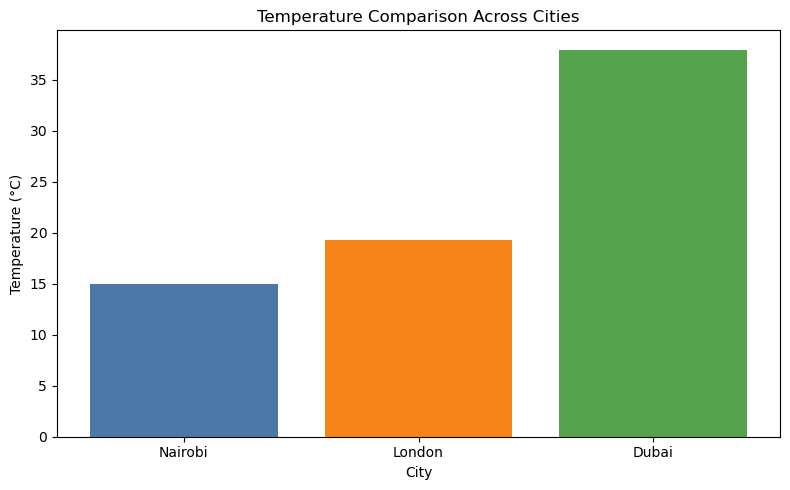

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["city"],
    weather_df["temperature_c"],
    color=["#4C78A8", "#F58518", "#54A24B"]
)

plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

### Humidity Comparison

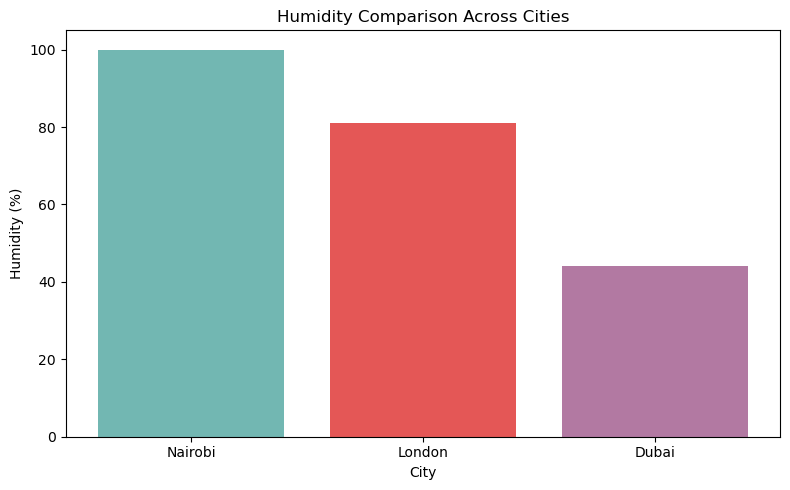

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["city"],
    weather_df["humidity_pct"],
    color=["#72B7B2", "#E45756", "#B279A2"]
)

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.tight_layout()
plt.show()

### Wind Speed Comparison

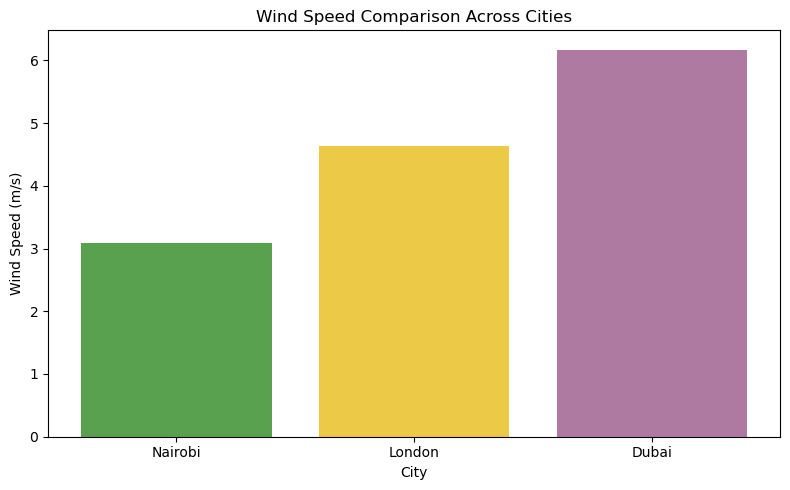

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["city"],
    weather_df["wind_speed_mps"],
    color=["#59A14F", "#EDC948", "#AF7AA1"]
)

plt.title("Wind Speed Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Wind Speed (m/s)")
plt.tight_layout()
plt.show()

## 12. Key Findings

The analysis of weather data collected from Nairobi, London, and Dubai produced the following findings:

- **Temperature:** Dubai recorded the highest temperature at **37.96°C**, while Nairobi recorded the lowest at **14.93°C**.
- **Humidity:** Nairobi recorded the highest humidity at **100%**, followed by London at **81%**, while Dubai recorded the lowest at **44%**.
- **Wind Speed:** Dubai recorded the strongest wind speed at **6.17 m/s**, while Nairobi recorded the lowest at **3.09 m/s**.
- **Weather Conditions:** Nairobi and London were experiencing **overcast clouds**, while Dubai had **broken clouds** at the time of data extraction.
- **Overall:** The results show noticeable differences in weather conditions across the three cities at the time the data was collected.

## 13. Conclusion

This project successfully demonstrated a basic ETL pipeline using the OpenWeather API.

Weather data was extracted for Nairobi, London, and Dubai using Python and the Requests library. The raw API responses were transformed into a structured Pandas DataFrame containing city, temperature, humidity, weather condition, wind speed, and date and time.

The transformed data was checked for missing values and duplicate records, and no data-quality issues were identified. The cleaned dataset was then stored as a CSV file for future analysis.

The analysis showed that Dubai had the highest temperature and wind speed, while Nairobi recorded the highest humidity. These results demonstrate how data retrieved from an API can be transformed into a structured dataset and used to generate simple, data-driven insights.

Through this project, I gained practical experience in API data extraction, data transformation, data validation, data storage, and visualization as part of an ETL workflow.